/var/folders/hs/b727hgzn71b8m1jmlbv2bq6r0000gn/T/ipykernel_36575/1302066145.py:64: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mu.flatten(), cov)


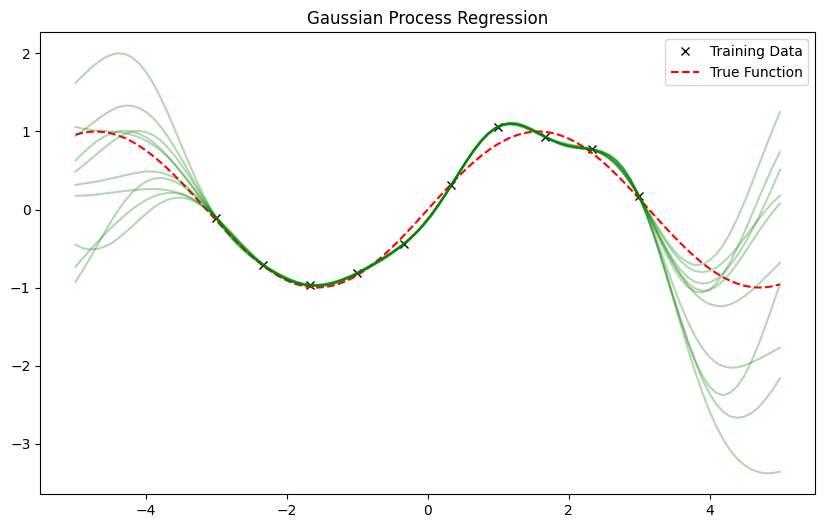

In [1]:
import torch
# torch multivariate normal distribution
import torch.distributions.multivariate_normal as dist
import matplotlib.pyplot as plt
import numpy as np

def rbf_kernel(x1, x2, length_scale=1.0, variance=1.0):
    x1 = x1.unsqueeze(1) if x1.dim() == 1 else x1
    x2 = x2.unsqueeze(1) if x2.dim() == 1 else x2
    
    # Compute pairwise squared distances
    sqdist = torch.cdist(x1, x2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / length_scale**2)


# Gaussian Process implementation
class GaussianProcess:
    def __init__(self, kernel=rbf_kernel, noise=1e-6):
        self.kernel = kernel
        self.noise = noise

    def fit(self, X_train, y_train, length_scale=1.0, variance=1.0):
        self.X_train = X_train
        self.y_train = y_train
        self.length_scale = length_scale
        self.variance = variance
        
        # Compute the kernel matrix K
        K = self.kernel(X_train, X_train, length_scale, variance)
        self.K_inv = torch.inverse(K + self.noise * torch.eye(len(X_train)))

    def predict(self, X_test):
        K_s = self.kernel(self.X_train, X_test, self.length_scale, self.variance)
        K_ss = self.kernel(X_test, X_test, self.length_scale, self.variance)
        
        # Predictive mean
        mu_s = K_s.T @ self.K_inv @ self.y_train
        
        # Predictive covariance
        cov_s = K_ss - K_s.T @ self.K_inv @ K_s
        return mu_s, cov_s

# Generate synthetic data
torch.manual_seed(42)
X_train = torch.linspace(-3, 3, 10).reshape(-1, 1)
y_train = torch.sin(X_train) + 0.1 * torch.randn(X_train.size())

X_test = torch.linspace(-5, 5, 100).reshape(-1, 1)

# Train GP and make predictions
gp = GaussianProcess()
gp.fit(X_train, y_train, length_scale=1.0, variance=1.0)

mu, cov = gp.predict(X_test)

# Convert covariance to standard deviation
std = torch.sqrt(torch.diag(cov))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, 'kx', label="Training Data")
plt.plot(X_test, torch.sin(X_test), 'r--', label="True Function")
for i in range(10):
    samples = np.random.multivariate_normal(mu.flatten(), cov)
    plt.plot(X_test, samples, 'g', alpha=0.3)
    
plt.legend()
plt.title("Gaussian Process Regression")
plt.show()


Step 0, NLL: 5.7159, Length Scale: 1.1000, Variance: 0.9000
Step 10, NLL: 3.9564, Length Scale: 1.6289, Variance: 0.5831
Step 20, NLL: 3.8519, Length Scale: 1.7222, Variance: 0.8483
Step 30, NLL: 3.8171, Length Scale: 1.8583, Variance: 0.9147
Step 40, NLL: 3.8076, Length Scale: 1.8406, Variance: 0.9781
Step 50, NLL: 3.8032, Length Scale: 1.8587, Variance: 0.9746
Step 60, NLL: 3.8021, Length Scale: 1.8549, Variance: 0.9585
Step 70, NLL: 3.8020, Length Scale: 1.8354, Variance: 0.9468
Step 80, NLL: 3.8019, Length Scale: 1.8405, Variance: 0.9301
Step 90, NLL: 3.8018, Length Scale: 1.8321, Variance: 0.9279


/var/folders/hs/b727hgzn71b8m1jmlbv2bq6r0000gn/T/ipykernel_2028/2072069325.py:99: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mu, cov.detach().numpy())


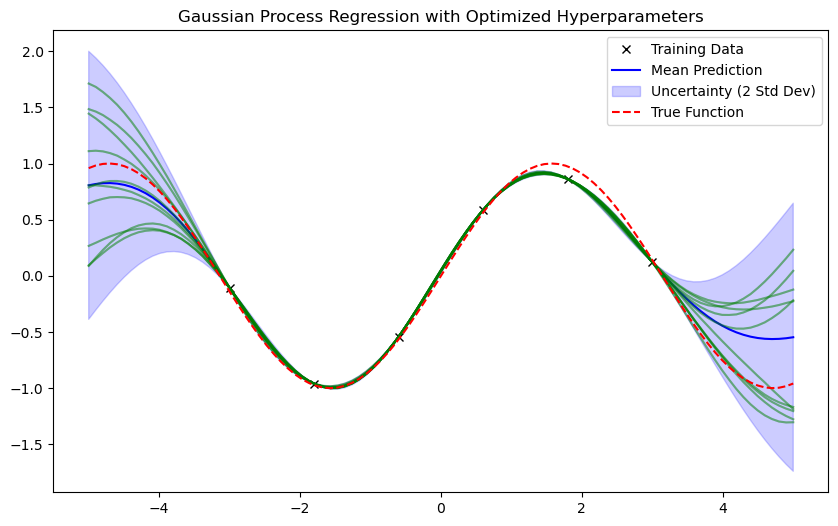

In [32]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the RBF kernel function
def rbf_kernel(x1, x2, length_scale, variance):
    x1 = x1.unsqueeze(1) if x1.dim() == 1 else x1
    x2 = x2.unsqueeze(1) if x2.dim() == 1 else x2
    sqdist = torch.cdist(x1, x2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / length_scale**2)

# Gaussian Process implementation with learnable parameters
class GaussianProcess:
    def __init__(self, kernel=rbf_kernel, noise=1e-6):
        self.kernel = kernel
        self.noise = noise
        self.length_scale = torch.nn.Parameter(torch.tensor(1.0, requires_grad=True))
        self.variance = torch.nn.Parameter(torch.tensor(1.0, requires_grad=True))


    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def compute_nll(self):
        K = self.kernel(self.X_train, self.X_train, self.length_scale, self.variance)
        K += self.noise * torch.eye(len(self.X_train))
        L = torch.linalg.cholesky(K)  # Cholesky decomposition for numerical stability
        alpha = torch.cholesky_solve(self.y_train, L)  # Solve K * alpha = y_train
        
        # Negative log-marginal likelihood
        nll = (
            0.5 * self.y_train.T @ alpha +
            torch.log(torch.diag(L)).sum() +
            0.5 * len(self.X_train) * torch.log(torch.tensor(2 * torch.pi))
        )
        return nll

    def predict(self, X_test):
        K = self.kernel(self.X_train, self.X_train, self.length_scale, self.variance)
        K += self.noise * torch.eye(len(self.X_train))
        K_inv = torch.linalg.inv(K)

        K_s = self.kernel(self.X_train, X_test, self.length_scale, self.variance)
        K_ss = self.kernel(X_test, X_test, self.length_scale, self.variance)

        mu_s = K_s.T @ K_inv @ self.y_train
        cov_s = K_ss - K_s.T @ K_inv @ K_s
        return mu_s, cov_s

# Generate synthetic data
torch.manual_seed(42)
X_train = torch.linspace(-3, 3, 6).reshape(-1, 1)
y_train = torch.sin(X_train) + 0.1 * torch.randn(X_train.size())

X_test = torch.linspace(-5, 5, 100).reshape(-1, 1)

# Train GP and optimize hyperparameters
gp = GaussianProcess()
gp.fit(X_train, y_train)

optimizer = optim.Adam([gp.length_scale, gp.variance], lr=0.1)

# Training loop
for step in range(100):
    optimizer.zero_grad()
    nll = gp.compute_nll()
    nll.backward()
    optimizer.step()
    
    # Constrain hyperparameters to positive values
    gp.length_scale.data = torch.clamp(gp.length_scale.data, min=1e-3)
    gp.variance.data = torch.clamp(gp.variance.data, min=1e-3)
    
    if step % 10 == 0:
        print(f"Step {step}, NLL: {nll.item():.4f}, Length Scale: {gp.length_scale.item():.4f}, Variance: {gp.variance.item():.4f}")

# Make predictions
mu, cov = gp.predict(X_test)
std = torch.sqrt(torch.diag(cov))

# Detach tensors for plotting
mu = mu.detach().squeeze().numpy()
std = std.detach().squeeze().numpy()

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, 'kx', label="Training Data")
plt.plot(X_test, mu, 'b', label="Mean Prediction")
plt.fill_between(
    X_test.squeeze().detach(),
    (mu - 2 * std).squeeze(),
    (mu + 2 * std).squeeze(),
    color='blue',
    alpha=0.2,
    label="Uncertainty (2 Std Dev)"
)
for i in range(10):
    samples = np.random.multivariate_normal(mu, cov.detach().numpy())
    plt.plot(X_test, samples, 'g', alpha=0.3)
    plt.plot(X_test, samples, 'g', alpha=0.3)
plt.plot(X_test, torch.sin(X_test), 'r--', label="True Function")
plt.legend()
plt.title("Gaussian Process Regression with Optimized Hyperparameters")
plt.show()



In [3]:
gp.length_scale


1.0

In [18]:
mu.squeeze().detach().numpy()

array([ 0.02642439,  0.03542455,  0.0466044 ,  0.06014459,  0.07610331,
        0.09436026,  0.11456087,  0.13606636,  0.15791589,  0.1788154 ,
        0.19715688,  0.21107456,  0.21854705,  0.21753252,  0.20613715,
        0.18279955,  0.14646631,  0.09674947,  0.03402141, -0.04054546,
       -0.12502673, -0.21686459, -0.3130605 , -0.41041017, -0.5057574 ,
       -0.596223  , -0.6794008 , -0.753462  , -0.8171971 , -0.86996394,
       -0.91158855, -0.9422221 , -0.9622047 , -0.9719621 , -0.97193897,
       -0.9626013 , -0.94448364, -0.9182404 , -0.8847029 , -0.8448788 ,
       -0.7998868 , -0.7508079 , -0.6984853 , -0.6433048 , -0.58498657,
       -0.5224983 , -0.4540768 , -0.37744105, -0.29016036, -0.19014764,
       -0.07620481,  0.05147655,  0.19096485,  0.3384727 ,  0.4885261 ,
        0.63444245,  0.76904523,  0.88553035,  0.9783478 ,  1.0439649 ,
        1.0813577 ,  1.0921518 ,  1.0803716 ,  1.0518366 ,  1.013283  ,
        0.9713524 ,  0.9316177 ,  0.8978031 ,  0.87130237,  0.85

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Iter 1/50 - Loss: 1.275   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 1.260   lengthscale: 0.644   noise: 0.644
Iter 3/50 - Loss: 1.241   lengthscale: 0.598   noise: 0.598
Iter 4/50 - Loss: 1.224   lengthscale: 0.559   noise: 0.555
Iter 5/50 - Loss: 1.209   lengthscale: 0.522   noise: 0.514
Iter 6/50 - Loss: 1.194   lengthscale: 0.486   noise: 0.476
Iter 7/50 - Loss: 1.179   lengthscale: 0.452   noise: 0.441
Iter 8/50 - Loss: 1.167   lengthscale: 0.419   noise: 0.408
Iter 9/50 - Loss: 1.155   lengthscale: 0.387   noise: 0.378
Iter 10/50 - Loss: 1.143   lengthscale: 0.357   noise: 0.352
Iter 11/50 - Loss: 1.133   lengthscale: 0.329   noise: 0.328
Iter 12/50 - Loss: 1.125   lengthscale: 0.302   noise: 0.307
Iter 13/50 - Loss: 1.118   lengthscale: 0.276   noise: 0.288
Iter 14/50 - Loss: 1.112   lengthscale: 0.252   noise: 0.273
Iter 15/50 - Loss: 1.108   lengthscale: 0.230   noise: 0.259
Iter 1

/var/folders/hs/b727hgzn71b8m1jmlbv2bq6r0000gn/T/ipykernel_36575/166152756.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_x = torch.tensor(X_train, dtype=torch.float32)
/var/folders/hs/b727hgzn71b8m1jmlbv2bq6r0000gn/T/ipykernel_36575/166152756.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(y_train, dtype=torch.float32)


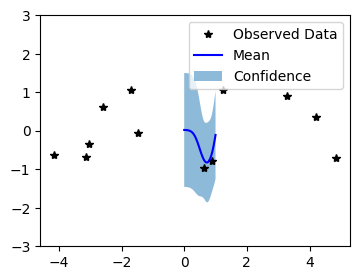

In [16]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Training data is 100 points in [0,1] inclusive regularly spaced
x = torch.linspace(-5, 5, 200)
# True function is sin(2*pi*x) with Gaussian noise
y = torch.sin(x * (2 * math.pi)) + torch.randn(x.size()) * math.sqrt(0.04)
random_indices = [196, 165, 112, 183,  37, 117,  17,  39,  66,  48,  70, 124]
test_ind = [i for i in range(200) if i not in random_indices]
X_train = x[random_indices]
y_train = y[random_indices]

X_test = x[test_ind]
y_test = y[test_ind]

# Convert data to PyTorch tensors
train_x = torch.tensor(X_train, dtype=torch.float32)
train_y = torch.tensor(y_train, dtype=torch.float32)


# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)


# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 50


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

f_preds = model(X_train)
y_preds = likelihood(model(X_train))

f_mean = f_preds.mean
f_var = f_preds.variance
f_covar = f_preds.covariance_matrix
# f_samples = f_preds.sample(sample_shape=torch.Size(1000,))

# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()
# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1, 51)
    observed_pred = likelihood(model(test_x))
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

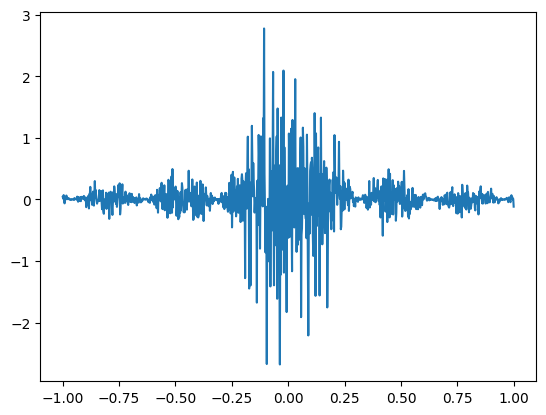

In [5]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
x = np.linspace(-1,1,N)
y = np.sinc(np.pi*x)[:,None] * np.random.randn(N, 1)
plt.figure()
plt.plot(x,y)
plt.show()

In [3]:
x.shape

(1000,)